In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt


In [3]:
data = yf.download("KO", period = '5y',interval='1d')

/tmp/ipykernel_16039/2879049062.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("KO", period = '5y',interval='1d')
[*********************100%***********************]  1 of 1 completed


In [4]:
data

Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2021-04-08,45.767384,45.991397,45.638148,45.810462,9695600
2021-04-09,45.819077,45.905234,45.500291,45.810459,10828200
2021-04-12,45.965546,46.137863,45.750149,45.948317,8565300
2021-04-13,45.741535,45.913853,45.500293,45.698457,11071700
2021-04-14,45.732910,45.827682,45.362429,45.646750,9787600
...,...,...,...,...,...
2026-03-31,76.050003,77.019997,75.510002,76.529999,18301800
2026-04-01,76.080002,76.360001,75.260002,76.150002,15834300


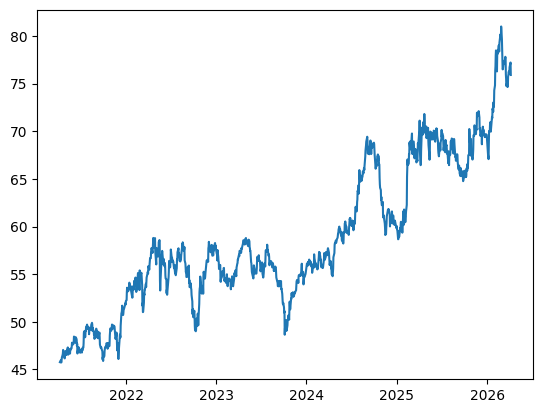

In [5]:
plt.plot(data['Close'])

In [6]:
data.index = pd.to_datetime(data.index)

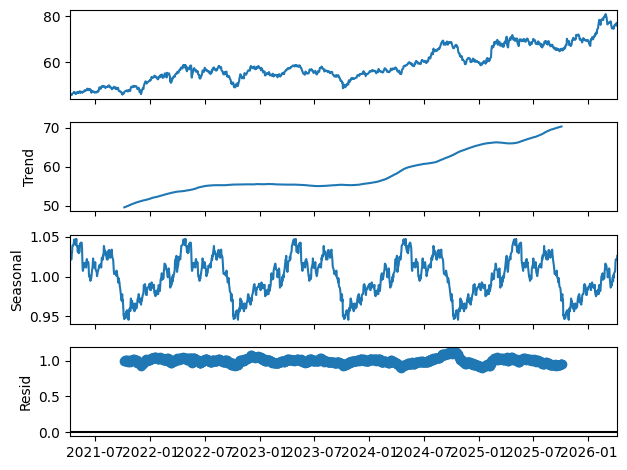

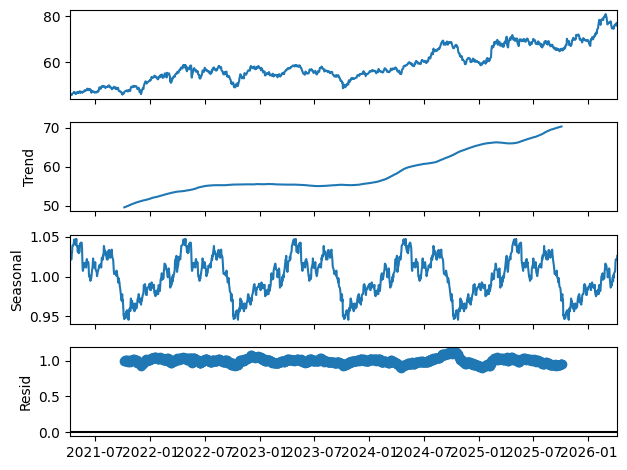

In [7]:
multiplicative_decomposition = seasonal_decompose(data['Close'],model='multiplicative',period=252)
multiplicative_decomposition.plot()

In [8]:
# Stationary Check
result = adfuller(data['Close'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -0.955799
p-value: 0.769042


<Axes: xlabel='Date'>

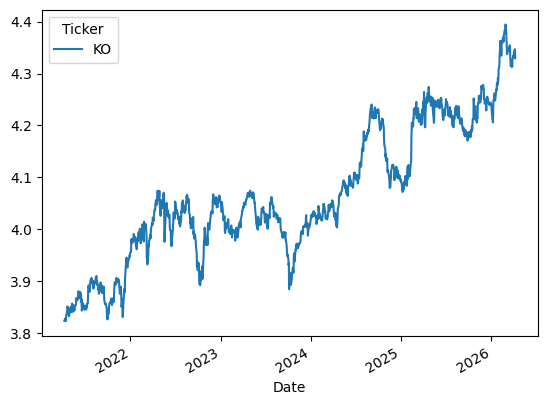

In [9]:
#Log transform
ts_log = np.log(data['Close'])
ts_log.plot()

<Axes: xlabel='Date'>

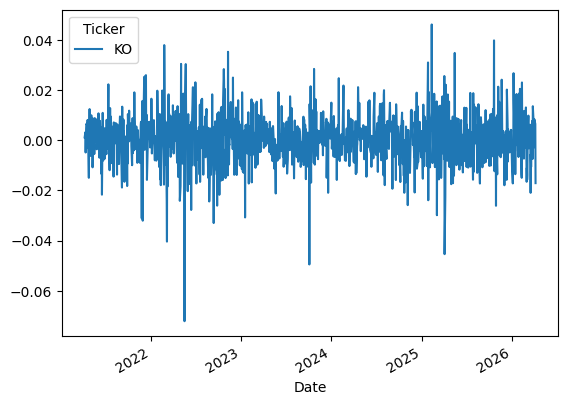

In [10]:
#First difference
ts = data['Close']
ts_diff = ts_log.diff()

ts_diff.dropna(inplace=True)


ts_diff.plot()

In [11]:
result_diff = adfuller(ts_diff)
print(result_diff[1])

0.0


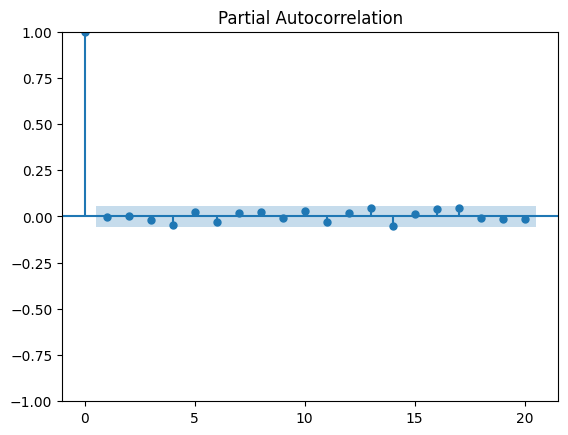

In [12]:
# p value finding

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(ts_diff, lags=20)
plt.show()

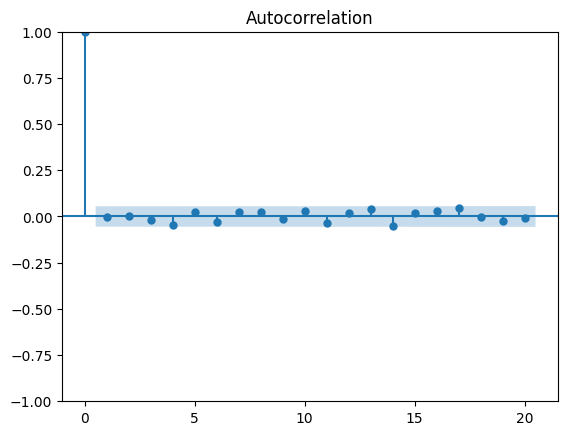

In [13]:
# q value finding

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts_diff, lags=20)
plt.show()

In [14]:
# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts_diff, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                     KO   No. Observations:                 1254
Model:                 ARIMA(1, 1, 1)   Log Likelihood                3994.549
Date:                Wed, 08 Apr 2026   AIC                          -7983.097
Time:                        09:10:14   BIC                          -7967.697
Sample:                             0   HQIC                         -7977.309
                               - 1254                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0017      0.023     -0.074      0.941      -0.047       0.044
ma.L1         -0.9998      0.075    -13.264      0.000      -1.148      -0.852
sigma2      9.905e-05   7.72e-06     12.831      0.0

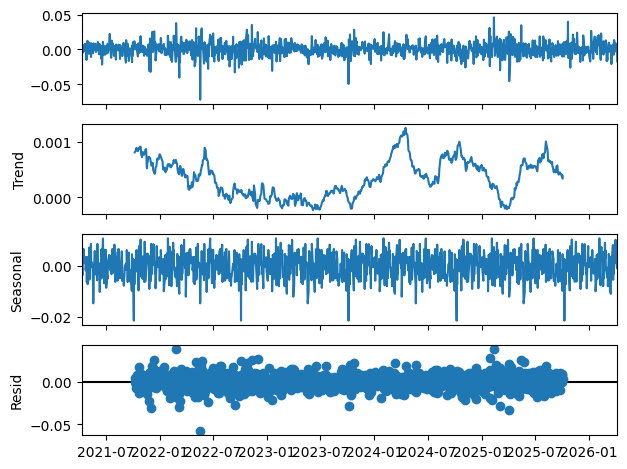

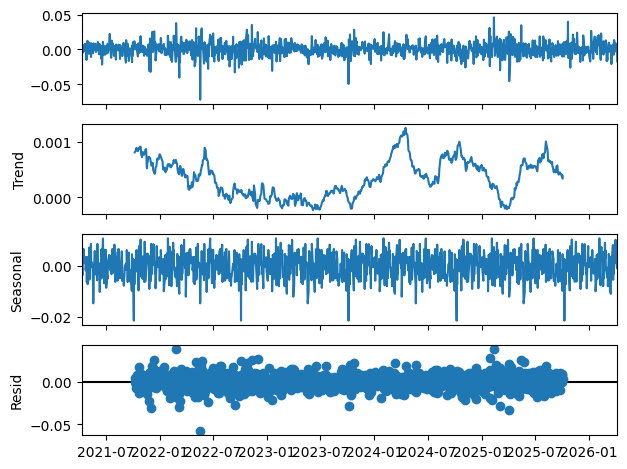

In [15]:
# SARIMA model
seasonal_decompose(ts_diff,model='additive',period=252).plot()

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts_diff,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 5))

sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                                KO   No. Observations:                 1254
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                3958.776
Date:                           Wed, 08 Apr 2026   AIC                          -7907.553
Time:                                   09:10:18   BIC                          -7881.906
Sample:                                        0   HQIC                         -7897.911
                                          - 1254                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0043      0.024      0.182      0.856      -0.042       0.051
ma.L1         -0.9952      0.008   -117.400

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


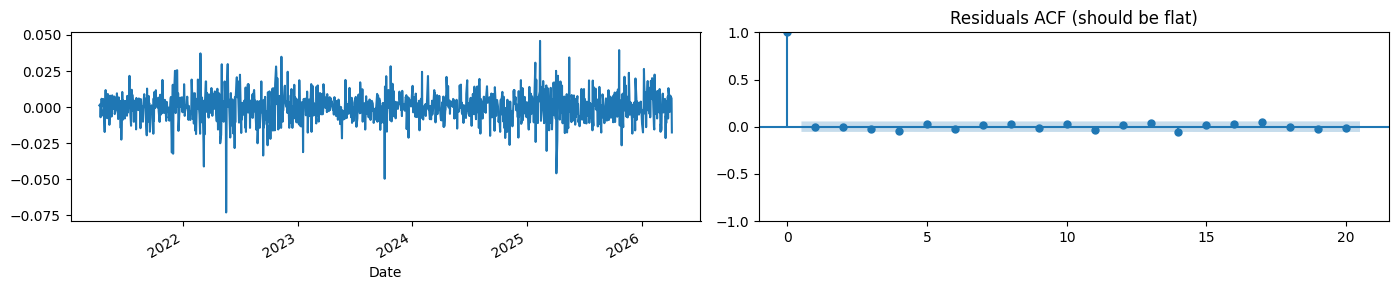

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

resid_best = model_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
resid_best.plot(ax=axes[0])
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid_best, lags=20, ax=axes[1], title='Residuals ACF (should be flat)')
plt.tight_layout()
plt.show()



In [18]:
# GARCH need check using het_arch
from statsmodels.stats.diagnostic import het_arch

resid = model_fit.resid

arch_test = het_arch(resid)
print(f"ARCH Test P-Value: {arch_test[1]:.6f}")


ARCH Test P-Value: 0.000473


In [19]:
# GARCH
!pip install arch
from arch import arch_model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.5 MB/s eta 0:00:00


In [20]:
resid = model_fit.resid

garch_model = arch_model(resid, p=1, q=1, vol='Garch', dist='normal')

garch_results = garch_model.fit(update_freq=5)

print(garch_results.summary())


Iteration:      5,   Func. Count:     57,   Neg. LLF: 1.8709324469829453e+17
Iteration:     10,   Func. Count:    128,   Neg. LLF: 21014356015731.27
Optimization terminated successfully    (Exit mode 0)
            Current function value: -4031.651425529596
            Iterations: 15
            Function evaluations: 142
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                4031.65
Distribution:                  Normal   AIC:                          -8055.30
Method:            Maximum Likelihood   BIC:                          -8034.77
                                        No. Observations:                 1254
Date:                Wed, Apr 08 2026   Df Residuals:                     1253
Time:   

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.935e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [21]:
conditional_vol = garch_results.conditional_volatility
conditional_vol

,cond_vol
Date,
2021-04-09,0.006394
2021-04-12,0.006332
2021-04-13,0.006285
2021-04-14,0.006414
2021-04-15,0.006344
...,...
2026-03-31,0.009728
2026-04-01,0.009515
2026-04-02,0.009283


In [22]:
arima_mean = model_fit.fittedvalues

In [23]:
arima_mean.shape

(1254,)

In [24]:
arima_mean = model_fit.fittedvalues

forecasted_price = [data['Close'].iloc[0]]
for i in range(1, len(arima_mean)):
    price = np.exp(arima_mean.iloc[i]) * data['Close'].iloc[i-1]
    forecasted_price.append(price)


In [25]:
forecasted_price_arr = np.array(forecasted_price)
conditional_vol_arr  = conditional_vol.values


In [26]:
print("forecasted_price_arr:", forecasted_price_arr.shape)
print("conditional_vol_arr :", conditional_vol_arr.shape)


forecasted_price_arr: (1254, 1)
conditional_vol_arr : (1254,)


In [27]:
data['Close'].shape

(1255, 1)

In [28]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
price_lower = []
price_upper = []

min_len = min(len(forecasted_price_arr), len(conditional_vol_arr))

for i in range(0, min_len):
    price_lower.append(forecasted_price_arr[i] - 1.0 * conditional_vol_arr[i] * forecasted_price_arr[i])
    price_upper.append(forecasted_price_arr[i] + 1.0 * conditional_vol_arr[i] * forecasted_price_arr[i])


In [29]:
price_lower, price_upper = np.array(price_lower), np.array(price_upper)

In [30]:
pip install backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 4.8 MB/s eta 0:00:00


In [31]:
min_len = min(len(data), len(forecasted_price_arr), len(price_lower), len(price_upper))

forecast = forecasted_price_arr[-min_len:]
lower = price_lower[-min_len:]
upper = price_upper[-min_len:]

bt_data = data[['Open', 'High', 'Low', 'Close']].iloc[-min_len:].copy()
bt_data = bt_data.reset_index()
bt_data['Forecast'] = forecast
bt_data['Lower'] = lower
bt_data['Upper'] = upper
bt_data = bt_data.set_index(bt_data.columns[0])
bt_data = bt_data.iloc[1:]


In [32]:
bt_data.shape

(1253, 7)

In [33]:
from backtesting import Backtest, Strategy

class ArimaGarch(Strategy):
    max_hold = 70
    def init(self):
        self.forecast  = self.data.Forecast
        self.lower     = self.data.Lower
        self.upper     = self.data.Upper
        self.entry_bar = 0

    def next(self):
        price    = self.data.Close[-1]
        forecast = self.forecast[-1]
        vol_band = self.upper[-1] - forecast
        if not self.position:
            predicted_return_positive = forecast > price
            predicted_return_negative = forecast < price

            if predicted_return_positive and price < self.lower[-1]:
                tp_price = price + vol_band * 4
                sl_price = price - vol_band * 4
                self.buy(sl=sl_price, tp=tp_price)
                self.entry_bar = len(self.data.Close)

            elif predicted_return_negative and price > self.upper[-1]:
                tp_price = price - vol_band * 4
                sl_price = price + vol_band * 4
                self.sell(sl=sl_price, tp=tp_price)
                self.entry_bar = len(self.data.Close)

        else:
            bars_held = len(self.data.Close) - self.entry_bar
            if bars_held >= self.max_hold:
                self.position.close()
            elif self.position.is_long  and price >= self.upper[-1]:
                self.position.close()
            elif self.position.is_short and price <= self.lower[-1]:
                self.position.close()


/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [34]:
bt = Backtest(bt_data, ArimaGarch, cash=10000, commission=.001)
stats = bt.run()

print(stats)


Backtest.run:   0%|          | 0/1252 [00:00<?, ?bar/s]

/tmp/ipykernel_16039/780242923.py:2: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


Start                     2021-04-12 00:00:00
End                       2026-04-07 00:00:00
Duration                   1821 days 00:00:00
Exposure Time [%]                    98.16441
Equity Final [$]                   15703.6243
Equity Peak [$]                    15973.4838
Commissions [$]                    1499.88092
Return [%]                           57.03624
Buy & Hold Return [%]                65.14544
Return (Ann.) [%]                     9.50122
Volatility (Ann.) [%]                17.20355
CAGR [%]                              6.44458
Sharpe Ratio                          0.55228
Sortino Ratio                          0.8803
Calmar Ratio                          0.49497
Alpha [%]                            -3.08752
Beta                                  0.92292
Max. Drawdown [%]                    -19.1955
Avg. Drawdown [%]                    -3.14076
Max. Drawdown Duration      756 days 00:00:00
Avg. Drawdown Duration       45 days 00:00:00
# Trades                          

In [35]:
bt.plot()

GridPlot(id='p1288', ...)